Dämpfungskonstante delta: -0.0029 1/s


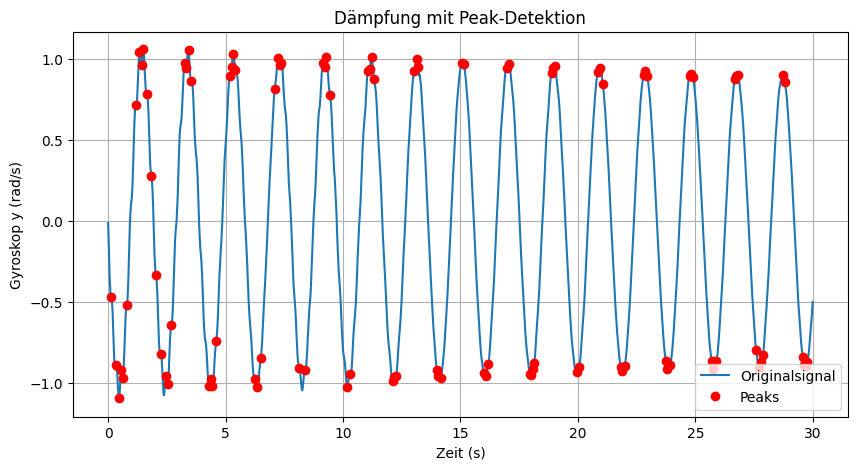

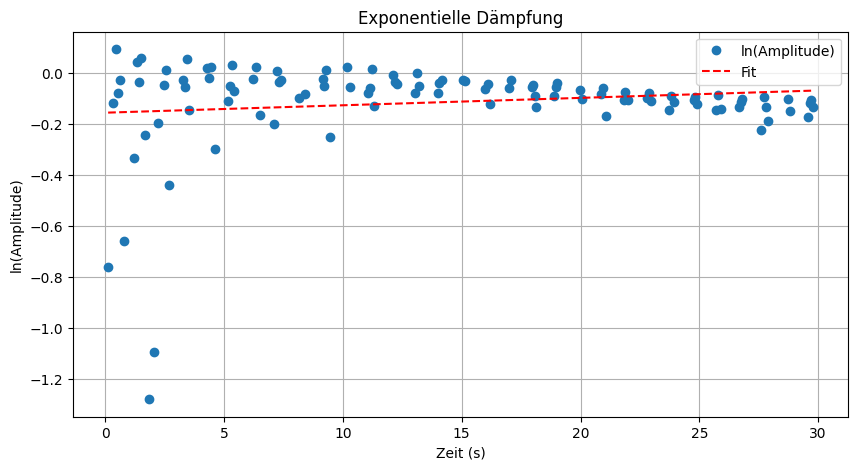

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

start_time = 20.3
end_time = 100.3

# CSV-Datei laden und Zeitfenster anwenden
df = pd.read_csv("data/Gyroscope.csv")
df = df[(df['Time (s)'] >= start_time) & (df['Time (s)'] <= end_time)]
df['Zeit_Angepasst'] = df['Time (s)'] - start_time

t = df['Zeit_Angepasst']
y = df['Gyroscope y (rad/s)']

# Peaks finden
peaks, _ = find_peaks(y, distance=30)  # distance ggf. anpassen
t_peaks = t.iloc[peaks]
y_peaks = y.iloc[peaks]

# Logarithmus der Amplituden
log_amplituden = np.log(np.abs(y_peaks))

# Fit-Funktion
def linear(t, a, delta):
    return a - delta * t

# Curve-Fit anwenden
params, _ = curve_fit(linear, t_peaks, log_amplituden)
a_fit, delta = params

print(f"Dämpfungskonstante delta: {delta:.4f} 1/s")

# Plot: Originalsignal mit Peaks
plt.figure(figsize=(10, 5))
plt.plot(t, y, label="Originalsignal")
plt.plot(t_peaks, y_peaks, "ro", label="Peaks")
plt.xlabel("Zeit (s)")
plt.ylabel("Gyroskop y (rad/s)")
plt.legend()
plt.title("Dämpfung mit Peak-Detektion")
plt.grid()
plt.show()

# Plot: Logarithmus der Amplituden
plt.figure(figsize=(10, 5))
plt.plot(t_peaks, log_amplituden, "o", label="ln(Amplitude)")
plt.plot(t_peaks, linear(t_peaks, *params), "r--", label="Fit")
plt.xlabel("Zeit (s)")
plt.ylabel("ln(Amplitude)")
plt.title("Exponentielle Dämpfung")
plt.legend()
plt.grid()
plt.show()
